# Graphs for Demand Exercise

NOTE: The scripts below requires python and an installation of the pybalmorel module. This module is very new, so be critical. Feel free to post issues [here](https://github.com/Mathias157/pybalmorel/issues)

**Installation:**

Open a terminal, activate your virtual environment and write:

`pip install pybalmorel`

## Loading Results

In [2]:
!pip install pybalmorel

In [3]:
import pybalmorel 
import matplotlib.pyplot as plt

In [73]:
from pybalmorel import MainResults
from pybalmorel.formatting import balmorel_colours

# Write the exact names of the scenarios and the path (or paths) that they aC:\\Users\\Bruger\\OneDrive\\Documents\\Master\\4. June 2026\\Large scale energy system analysis\\Excersice\\Lecture_2\\BalmorelSimpleModel_LP\\BalmorelSimpleModel_LP\\Balmorel\\Lecture_2_Ex_0\\model\\re in
res = MainResults(files=["S1_no_limit.gdx", "S1_limit_2000000.gdx", "S1_limit_1000000.gdx", "S1_limit_0.gdx", 
                                                  ], 
                  paths='C:\\Users\\Bruger\\OneDrive\\Documents\\Master\\4. June 2026\\Large scale energy system analysis\\LSESAub\\0_results_for_python_limit_CO2')

Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python_limit_CO2\S1_no_limit.gdx
Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python_limit_CO2\S1_limit_2000000.gdx
Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python_limit_CO2\S1_limit_1000000.gdx
Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python_limit_CO2\S1_limit_0.gdx


c:\Users\Bruger\miniforge3\envs\anaconda3\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (54.0.0) differs from the API version (53.5.1).
  ws = gams.GamsWorkspace()


## Installed Capacities

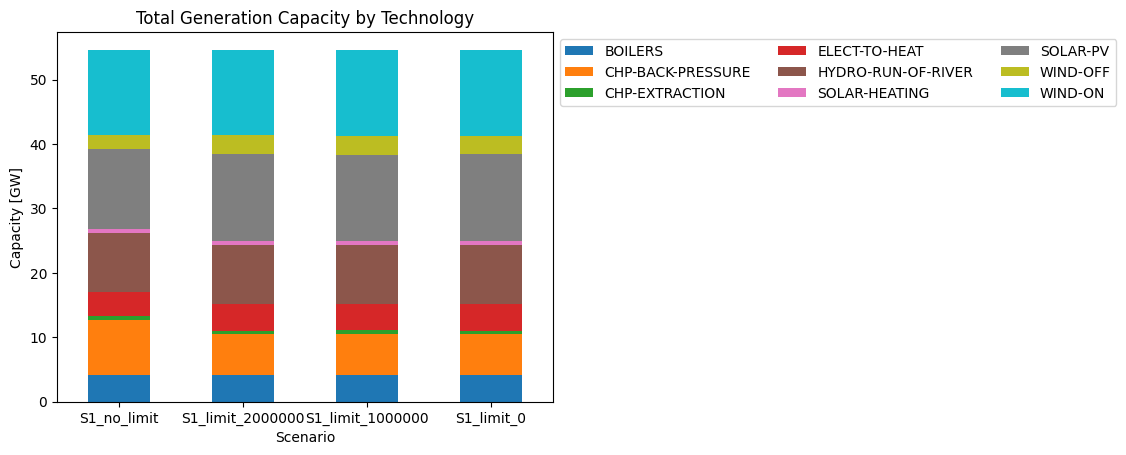

In [63]:
obj = res.get_result('G_CAP_YCRAF')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                      columns=['Technology'],  
                      values='Value',
                      aggfunc='sum')

# Define the target technologies (Note: matching 'HYDRO-RESERVOIRS' to your original image legend)
target_techs = ['SOLAR-PV', 'WIND-ON', 'WIND-OFF']

#Eliminate the storage technologies 'H2-STORAGE', 'HYDRO-RESERVOIR', 'HYDRO-RUN-OF-RIVER', 'INTERSEASONAL-HEAT-STORAGE', 'INTRASEASONAL-HEAT-STORAGE', 'FUELCELL', 'INTRASEASONAL-ELEC-STORAGE'
elim=['H2-STORAGE', 'HYDRO-RESERVOIRS', 'INTERSEASONAL-HEAT-STORAGE', 'INTRASEASONAL-HEAT-STORAGE', 'FUELCELL', 'INTRASEASONAL-ELECT-STORAGE', 'CONDENSING', 'ELEC-TO-HEAT', 'ELECTROLYZER', 'STEAMREFORMING']
obj = obj.loc[:, ~obj.columns.isin(elim)]

# 1. Sum up all other columns into 'OTHER'
# obj['OTHER'] = obj.loc[:, ~obj.columns.isin(target_techs)].sum(axis=1)

# 2. Keep ONLY the target technologies + 'OTHER'
# obj = obj[target_techs + ['OTHER']]

# Make the order of scenarios correct
obj = obj.reindex(['S1_no_limit', 'S1_limit_2000000', 'S1_limit_1000000', 'S1_limit_0'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['tab10'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='Capacity [GW]', rot=0, 
              color=color_list) 
ax.set_title('Total Generation Capacity by Technology')
ax.legend(bbox_to_anchor=(1, 1), ncols=3)

In [64]:
print(obj)

Technology        BOILERS  CHP-BACK-PRESSURE  CHP-EXTRACTION  ELECT-TO-HEAT  \
Scenario                                                                      
S1_no_limit        4.0529           8.652541        0.527778       3.748099   
S1_limit_2000000   4.0529           6.432664        0.527778       4.115956   
S1_limit_1000000   4.0529           6.465228        0.527778       4.120130   
S1_limit_0         4.0529           6.449850        0.527778       4.059908   

Technology        HYDRO-RUN-OF-RIVER  SOLAR-HEATING   SOLAR-PV  WIND-OFF  \
Scenario                                                                   
S1_no_limit                 9.172635        0.65007  12.352468  2.232700   
S1_limit_2000000            9.172635        0.65007  13.442388  2.932078   
S1_limit_1000000            9.172635        0.65007  13.340549  2.939897   
S1_limit_0                  9.172635        0.65007  13.582222  2.813368   

Technology          WIND-ON  
Scenario                     
S1_no_li

## Storage Installed Capacities

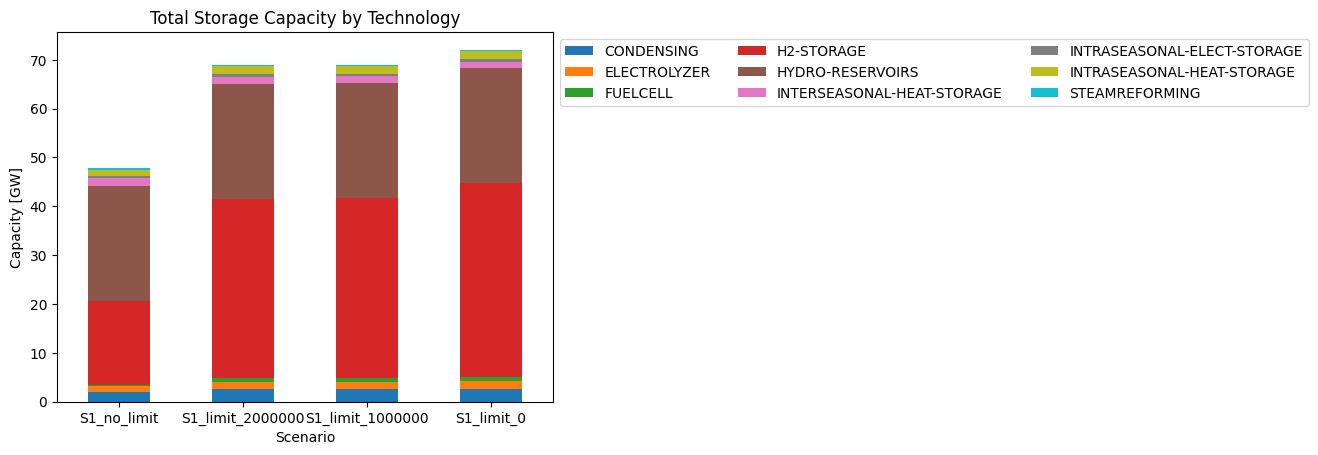

In [65]:
obj = res.get_result('G_CAP_YCRAF')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                      columns=['Technology'],  
                      values='Value',
                      aggfunc='sum')

elim=['BOILERS', 'SOLAR-PV', 'WIND-ON', 'WIND-OFF', 'SOLAR-HEATING', 'HYDRO-RUN-OF-RIVER', 'ELECT-TO-HEAT', 'CHP-EXTRACTION', 'CHP-BACK-PRESSURE']
obj = obj.loc[:, ~obj.columns.isin(elim)]

# 1. Sum up all other columns into 'OTHER'
# obj['OTHER'] = obj.loc[:, ~obj.columns.isin(target_techs)].sum(axis=1)

# 2. Keep ONLY the target technologies + 'OTHER'
# obj = obj[target_techs + ['OTHER']]

# Make the order of scenarios correct
obj = obj.reindex(['S1_no_limit', 'S1_limit_2000000', 'S1_limit_1000000', 'S1_limit_0'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['tab10'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='Capacity [GW]', rot=0, 
              color=color_list) 
ax.set_title('Total Storage Capacity by Technology')
ax.legend(bbox_to_anchor=(1, 1), ncols=3)

In [66]:
print(obj)

Technology        CONDENSING  ELECTROLYZER  FUELCELL  H2-STORAGE  \
Scenario                                                           
S1_no_limit         2.003403      1.112618  0.216861   17.260289   
S1_limit_2000000    2.498590      1.526573  0.745808   36.780760   
S1_limit_1000000    2.541970      1.525583  0.785160   36.877782   
S1_limit_0          2.546215      1.579446  0.878004   39.796269   

Technology        HYDRO-RESERVOIRS  INTERSEASONAL-HEAT-STORAGE  \
Scenario                                                         
S1_no_limit              23.470954                    1.667462   
S1_limit_2000000         23.470954                    1.390850   
S1_limit_1000000         23.470954                    1.382550   
S1_limit_0               23.470954                    1.372345   

Technology        INTRASEASONAL-ELECT-STORAGE  INTRASEASONAL-HEAT-STORAGE  \
Scenario                                                                    
S1_no_limit                          0.4

## Boiler Capacity Composition

Fuel              BIOGAS  BIOOIL    COAL   FUELOIL  LIGHTOIL       LNG  \
Scenario                                                                 
S1_limit_0        0.0057  0.1979  0.0192  0.367933   0.68569  0.153067   
S1_limit_1000000  0.0057  0.1979  0.0192  0.367933   0.68569  0.153067   
S1_limit_2000000  0.0057  0.1979  0.0192  0.367933   0.68569  0.153067   
S1_no_limit       0.0057  0.1979  0.0192  0.367933   0.68569  0.153067   

Fuel              MUNIWASTE    NATGAS  OTHERGAS    STRAW  WASTEHEAT  \
Scenario                                                              
S1_limit_0           0.0523  1.335113    0.0083  0.30558     0.1096   
S1_limit_1000000     0.0523  1.335113    0.0083  0.30558     0.1096   
S1_limit_2000000     0.0523  1.335113    0.0083  0.30558     0.1096   
S1_no_limit          0.0523  1.335113    0.0083  0.30558     0.1096   

Fuel              WOODCHIPS  WOODPELLETS  WOODWASTE  
Scenario                                             
S1_limit_0         0

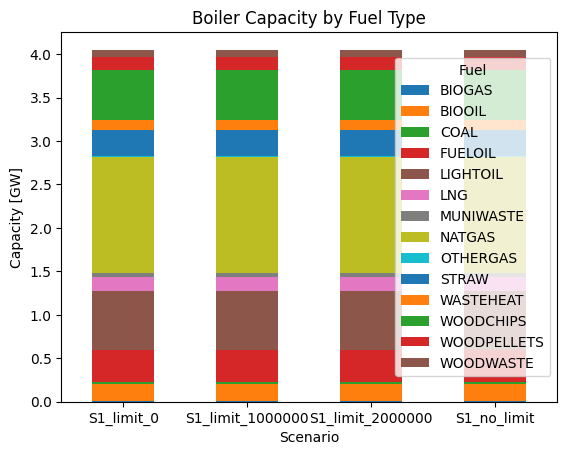

In [67]:
#Look at fuel type in the Boiler technology
obj_boiler = res.get_result('G_CAP_YCRAF')
obj_boiler = obj_boiler[obj_boiler['Technology'] == 'BOILERS']
obj_boiler = obj_boiler.pivot_table(index='Scenario', columns='Fuel', values='Value', aggfunc='sum')
ax = obj_boiler.plot(kind='bar', stacked=True, ylabel='Capacity [GW]', rot=0, color=color_list)
ax.set_title('Boiler Capacity by Fuel Type')
print(obj_boiler)

In [68]:
print(obj)

Technology        CONDENSING  ELECTROLYZER  FUELCELL  H2-STORAGE  \
Scenario                                                           
S1_no_limit         2.003403      1.112618  0.216861   17.260289   
S1_limit_2000000    2.498590      1.526573  0.745808   36.780760   
S1_limit_1000000    2.541970      1.525583  0.785160   36.877782   
S1_limit_0          2.546215      1.579446  0.878004   39.796269   

Technology        HYDRO-RESERVOIRS  INTERSEASONAL-HEAT-STORAGE  \
Scenario                                                         
S1_no_limit              23.470954                    1.667462   
S1_limit_2000000         23.470954                    1.390850   
S1_limit_1000000         23.470954                    1.382550   
S1_limit_0               23.470954                    1.372345   

Technology        INTRASEASONAL-ELECT-STORAGE  INTRASEASONAL-HEAT-STORAGE  \
Scenario                                                                    
S1_no_limit                          0.4

## Production by Technology

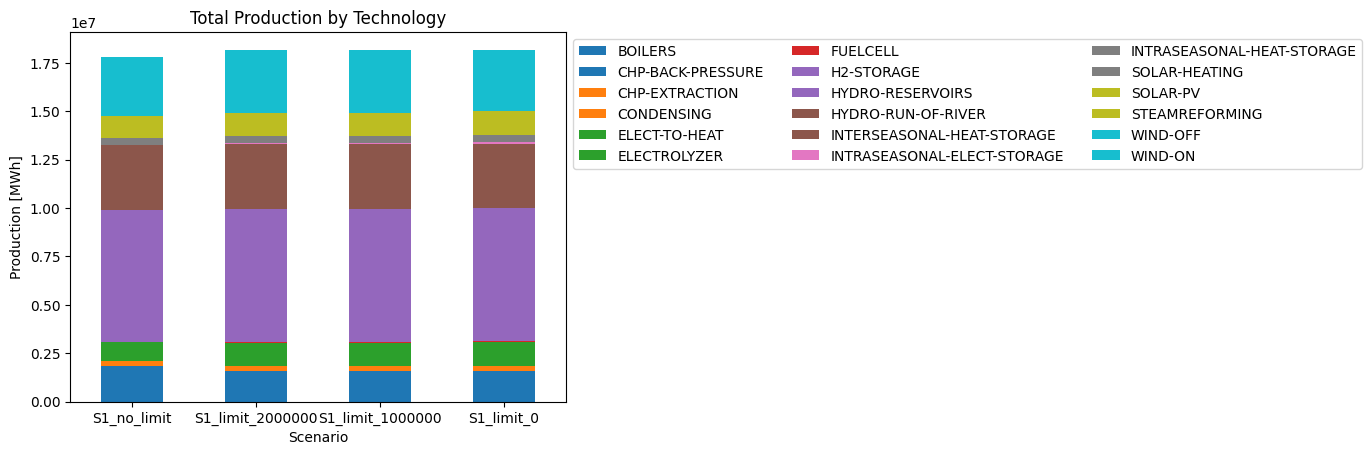

In [70]:
obj = res.get_result('PRO_YCRAGFST')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                      columns=['Technology'],  
                      values='Value',
                      aggfunc='sum')

# Define the target technologies (Note: matching 'HYDRO-RESERVOIRS' to your original image legend)
target_techs = ['SOLAR-PV', 'WIND-ON', 'WIND-OFF']

#Eliminate the storage technologies 'H2-STORAGE', 'HYDRO-RESERVOIR', 'HYDRO-RUN-OF-RIVER', 'INTERSEASONAL-HEAT-STORAGE', 'INTRASEASONAL-HEAT-STORAGE', 'FUELCELL', 'INTRASEASONAL-ELEC-STORAGE'
# elim=['H2-STORAGE', 'HYDRO-RESERVOIRS', 'INTERSEASONAL-HEAT-STORAGE', 'INTRASEASONAL-HEAT-STORAGE', 'FUELCELL', 'INTRASEASONAL-ELECT-STORAGE', 'CONDENSING', 'ELEC-TO-HEAT', 'ELECTROLYZER', 'STEAMREFORMING']
# obj = obj.loc[:, ~obj.columns.isin(elim)]

# 1. Sum up all other columns into 'OTHER'
# obj['OTHER'] = obj.loc[:, ~obj.columns.isin(target_techs)].sum(axis=1)

# 2. Keep ONLY the target technologies + 'OTHER'
# obj = obj[target_techs + ['OTHER']]

# Make the order of scenarios correct
obj = obj.reindex(['S1_no_limit', 'S1_limit_2000000', 'S1_limit_1000000', 'S1_limit_0'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['tab10'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='Production [MWh]', rot=0, 
              color=color_list) 
ax.set_title('Total Production by Technology')
ax.legend(bbox_to_anchor=(1, 1), ncols=3)

In [71]:
print(obj)

Technology              BOILERS  CHP-BACK-PRESSURE  CHP-EXTRACTION  \
Scenario                                                             
S1_no_limit       171871.850757       1.670447e+06    88538.824397   
S1_limit_2000000  222187.164770       1.353362e+06             NaN   
S1_limit_1000000  221718.615886       1.354560e+06             NaN   
S1_limit_0        223739.703988       1.363048e+06             NaN   

Technology           CONDENSING  ELECT-TO-HEAT   ELECTROLYZER      FUELCELL  \
Scenario                                                                      
S1_no_limit       157418.333053  573040.904215  420408.973050   7724.076159   
S1_limit_2000000  238109.568485  714461.808006  518574.274637  36470.531917   
S1_limit_1000000  240300.963656  713406.074660  519971.572457  37154.446246   
S1_limit_0        242888.311181  703398.671578  531494.848387  42771.153947   

Technology           H2-STORAGE  HYDRO-RESERVOIRS  HYDRO-RUN-OF-RIVER  \
Scenario                       

## Boiler Production 

Fuel                BIOGAS    BIOOIL       COAL         LNG     MUNIWASTE  \
Scenario                                                                    
S1_no_limit       8.434989       NaN  37.208723  107.196546  32972.961057   
S1_limit_2000000  1.686998  58.90354        NaN         NaN  32972.961057   
S1_limit_1000000  1.686998  58.90354        NaN         NaN  32972.961057   
S1_limit_0        1.686998  58.90354        NaN         NaN  32972.961057   

Fuel                  NATGAS         STRAW     WASTEHEAT      WOODCHIPS  \
Scenario                                                                  
S1_no_limit       145.688379   4642.422985  35609.954888   70803.151860   
S1_limit_2000000         NaN  24052.477510  34832.405209  100316.459824   
S1_limit_1000000         NaN  23896.392172  34826.973732   99980.397787   
S1_limit_0               NaN  24533.462911  34813.980838  101528.066987   

Fuel              WOODPELLETS     WOODWASTE  
Scenario                                

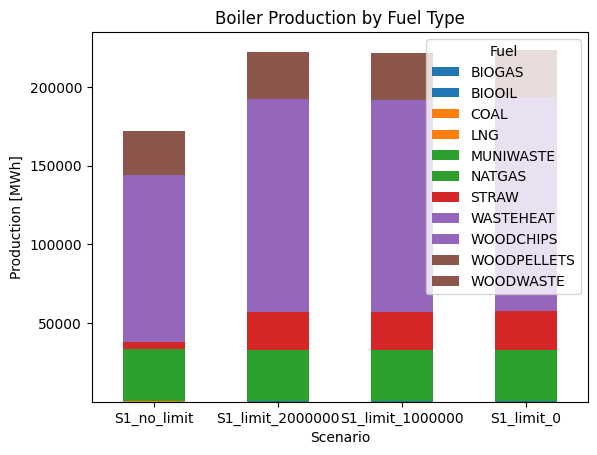

In [76]:
#Look at fuel type in the Boiler technology
obj_boiler = res.get_result('PRO_YCRAGFST')
obj_boiler = obj_boiler[obj_boiler['Technology'] == 'BOILERS']
obj_boiler = obj_boiler.pivot_table(index='Scenario', columns='Fuel', values='Value', aggfunc='sum')
obj_boiler = obj_boiler.reindex(['S1_no_limit', 'S1_limit_2000000', 'S1_limit_1000000', 'S1_limit_0'])
ax = obj_boiler.plot(kind='bar', stacked=True, ylabel='Production [MWh]', rot=0, color=color_list)
ax.set_title('Boiler Production by Fuel Type')
print(obj_boiler)

## System Costs

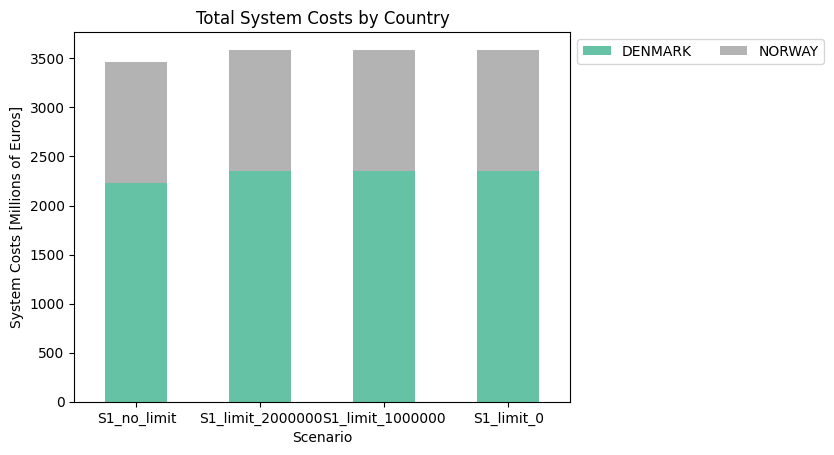

In [77]:
obj = res.get_result('OBJ_YCR')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                columns=['Country'],  
                values='Value',
                aggfunc='sum')

# Make the order of scenarios correct
obj = obj.reindex(['S1_no_limit', 'S1_limit_2000000', 'S1_limit_1000000', 'S1_limit_0'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='System Costs [Millions of Euros]', rot=0, 
              color=color_list) 
ax.set_title('Total System Costs by Country')
ax.legend(bbox_to_anchor=(1, 1), ncols=4)

In [78]:
print(obj)

Country               DENMARK       NORWAY
Scenario                                  
S1_no_limit       2228.947309  1237.080814
S1_limit_2000000  2348.630018  1235.479279
S1_limit_1000000  2351.179783  1235.577772
S1_limit_0        2354.659571  1235.861772


## Emissions

Symbol contents are empty


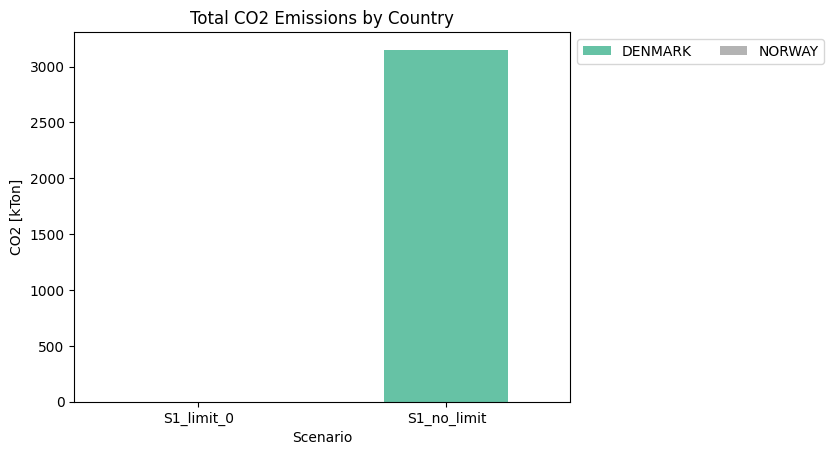

In [79]:
obj = res.get_result('EMI_YCRAG')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                      columns=['C'],  
                      values='Value',
                      aggfunc='sum')

# Make the order of scenarios correct
obj = obj.reindex(['S1_limit_0', 'S1_no_limit'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='CO2 [kTon]', rot=0, 
              color=color_list) 
ax.set_title('Total CO2 Emissions by Country')
ax.legend(bbox_to_anchor=(1, 1), ncols=4)

In [80]:
print(obj)

C                DENMARK    NORWAY
Scenario                          
S1_limit_0           NaN       NaN
S1_no_limit  3151.365529  0.611583


## Hourly Electricity Price

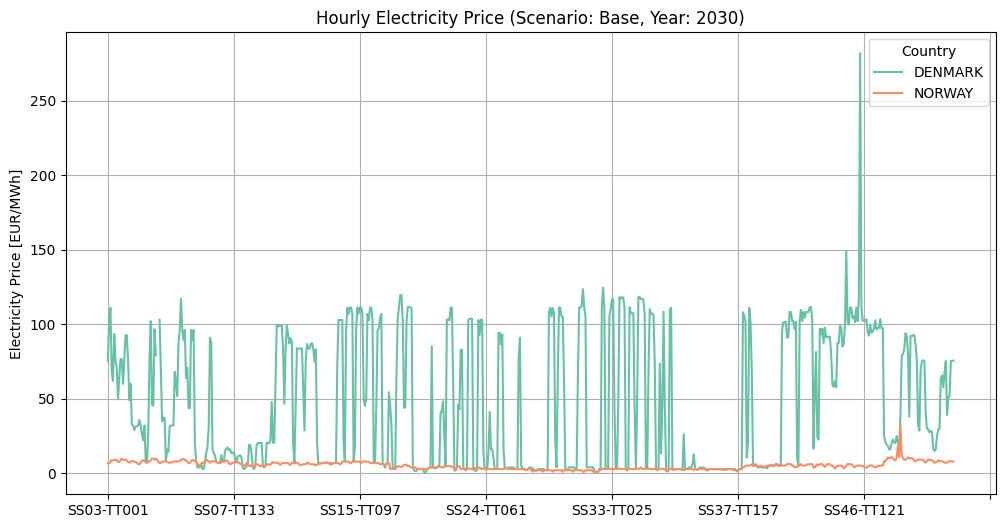

In [60]:
# 1. Pull raw Balmorel GDX results
obj = res.get_result('EL_PRICE_YCRST')

# METHOD B: Remove any row where the price is greater than 1000
obj = obj[obj['Value'] <= 300]

# 3. Pivot with Time dimensions as rows, and Countries as columns
hourly_prices = obj.pivot_table(
    index=['Season', 'Time'],  # This preserves the chronological time order
    columns=['Country'],  
    values='Value',
    aggfunc='mean'             # Use mean instead of sum in case of duplicate entries
)

# 4. Optional: Flatten the MultiIndex so pandas can plot it sequentially on the x-axis
hourly_prices.index = [f"S{s}-T{t}" for s, t in hourly_prices.index]

# 5. Plot the profile
cmap = plt.colormaps['Set2']
ax = hourly_prices.plot(kind='line', ylabel='Electricity Price [EUR/MWh]', color=cmap.colors, figsize=(12, 6))
ax.set_title('Hourly Electricity Price (Scenario: Base, Year: 2030)')
plt.grid(True)

Symbol contents are empty


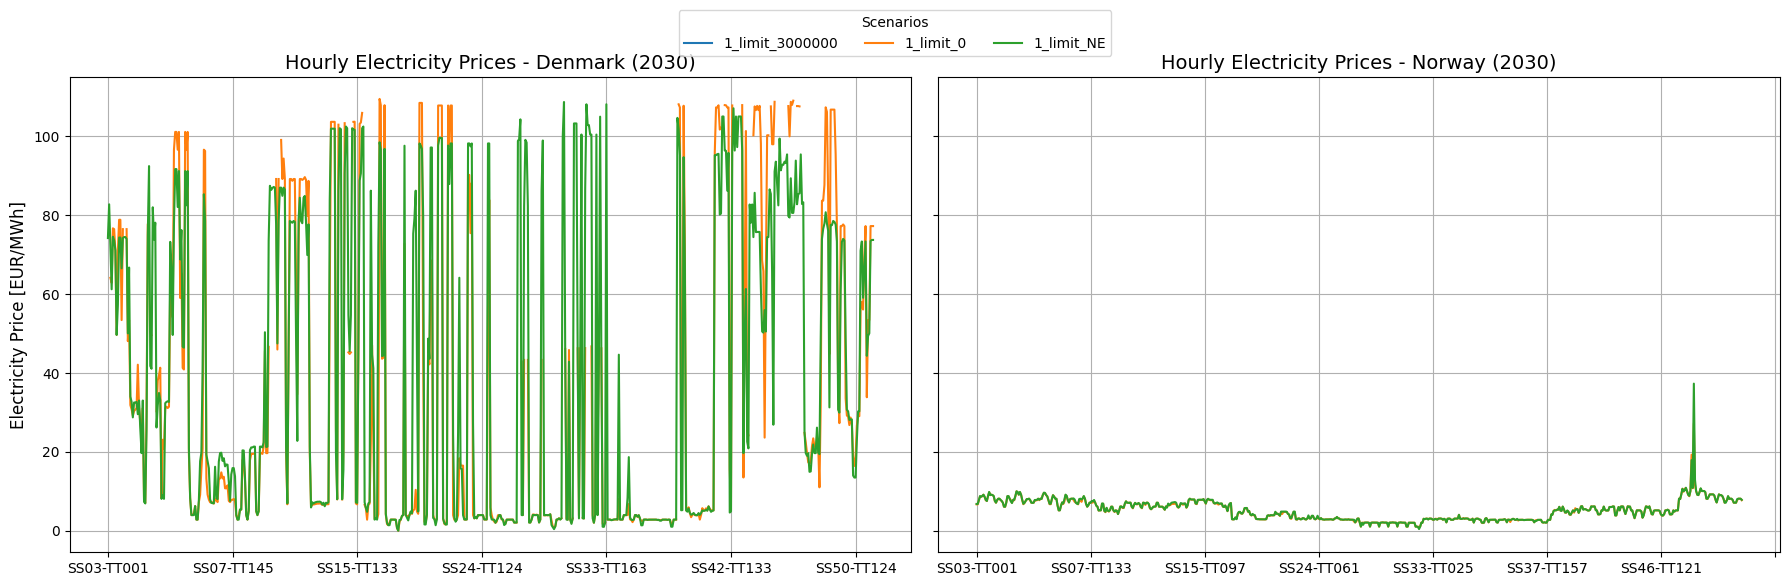

In [22]:
# 1. Pull raw Balmorel GDX results
obj = res.get_result('EL_PRICE_YCRST')

# 2. Basic cleaning: Filter for your target year and clean up extreme price spikes
obj = obj[obj['Value'] <= 110]

# --- Setup the two side-by-side plots ---
fig, (ax_dk, ax_nor) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
cmap = plt.colormaps['tab10']

# Define custom ordered list for scenario lines
scenario_order = ['1_limit_3000000', '1_limit_0', '1_limit_NE']

# ==========================================
# PLOT 1: DENMARK
# ==========================================
# (Note: Check if your GDX uses 'DENMARK' or 'DK' based on your previous print)
obj_dk = obj[obj['Country'] == 'DENMARK']

prices_dk = obj_dk.pivot_table(
    index=['Season', 'Time'], 
    columns=['Scenario'], 
    values='Value', 
    aggfunc='mean'
).reindex(columns=scenario_order)

prices_dk.index = [f"S{s}-T{t}" for s, t in prices_dk.index]

prices_dk.plot(kind='line', ax=ax_dk, color=cmap.colors)
ax_dk.set_title('Hourly Electricity Prices - Denmark (2030)', fontsize=14)
ax_dk.set_ylabel('Electricity Price [EUR/MWh]', fontsize=12)
ax_dk.grid(True)
ax_dk.get_legend().remove() # Remove temporary legend to clean up spacing

# ==========================================
# PLOT 2: NORWAY
# ==========================================
# (Note: Check if your GDX uses 'NORWAY' or 'NO')
obj_nor = obj[obj['Country'] == 'NORWAY']

prices_nor = obj_nor.pivot_table(
    index=['Season', 'Time'], 
    columns=['Scenario'], 
    values='Value', 
    aggfunc='mean'
).reindex(columns=scenario_order)

prices_nor.index = [f"S{s}-T{t}" for s, t in prices_nor.index]

prices_nor.plot(kind='line', ax=ax_nor, color=cmap.colors)
ax_nor.set_title('Hourly Electricity Prices - Norway (2030)', fontsize=14)
ax_nor.grid(True)
ax_nor.get_legend().remove()

# ==========================================
# SHARED LEGEND
# ==========================================
# Place a single clean legend for the scenarios at the top or side
handles, labels = ax_dk.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncols=6, title="Scenarios")

plt.tight_layout(rect=[0, 0, 1, 0.92]) # Make room for the header legend
plt.show()